# Rapport d'Analyse — NYC Yellow Taxi 2024-2025

**Projet :** Pipeline de données NYC TLC  
**Périmètre :** Janvier 2024 → Mars 2025 (15 mois)  
**Source :** NYC Taxi & Limousine Commission — fichiers Parquet mensuels  
**Architecture :** RAW → STAGING (clean_trips) → FINAL (6 tables analytiques)

---

Ce rapport présente :
1. La qualité des données après nettoyage
2. Les KPIs calculés sur la couche FINAL
3. Les patterns et tendances identifiés

## 0. Setup

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import snowflake.connector
import os
import warnings
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv()

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (13, 5)

MONTH_NAMES = {1:'Jan',2:'Fev',3:'Mar',4:'Avr',5:'Mai',6:'Jun',
               7:'Jul',8:'Aou',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

conn = snowflake.connector.connect(
    account   = os.getenv('SNOWFLAKE_ACCOUNT'),
    user      = os.getenv('SNOWFLAKE_USER'),
    password  = os.getenv('SNOWFLAKE_PASSWORD'),
    warehouse = os.getenv('SNOWFLAKE_WAREHOUSE', 'NYC_TAXI_WH'),
    database  = os.getenv('SNOWFLAKE_DATABASE',  'NYC_TAXI_DB'),
    role      = os.getenv('SNOWFLAKE_ROLE',       'SYSADMIN')
)

def query(sql):
    df = pd.read_sql(sql, conn)
    df.columns = df.columns.str.lower()
    return df

print('Connexion Snowflake OK')

Connexion Snowflake OK


## 1. Pipeline — Enrichissements de la couche Silver

La couche Silver (STAGING) ne se limite pas au nettoyage des données brutes. Elle intègre également des **enrichissements structurels** conçus pour rendre chaque trajet directement exploitable dans les couches analytiques, sans répéter de logique métier dans chaque requête Gold ou ad hoc.

---

### 1.1 Référentiel de zones géographiques (seed CSV)

Le jeu de données TLC n'identifie les zones de prise en charge et de dépose que par des **codes numériques** (`PULocationID`, `DOLocationID`, valeurs entières de 1 à 265). Utilisés seuls, ces identifiants ne disent rien de la géographie réelle : un analyste ne peut pas savoir au premier coup d'œil que la zone 132 correspond à *JFK Airport* ou que la 161 est *Midtown Center*.

Pour pallier cela, nous avons intégré le fichier CSV officiel de la TLC — le **taxi zones lookup** — qui fait correspondre chaque code à un nom de zone, un borough et un identifiant de service. Ce fichier a été chargé comme **seed dbt** (`taxi_zones.csv`) et est joint directement en couche Silver.

**Pourquoi ce choix architectural ?**
- Centraliser le mapping en Silver évite de le dupliquer dans chaque modèle Gold.
- Les noms de zones sont ainsi disponibles partout dans le pipeline sans JOIN supplémentaire.
- En cas de mise à jour du référentiel TLC, une seule modification suffit (le seed), et tous les modèles en aval se mettent à jour automatiquement à la prochaine exécution dbt.

---

### 1.2 Douze colonnes dérivées en couche Silver

Plutôt que de recalculer les mêmes expressions dans chaque modèle analytique, la couche Silver **matérialise 12 colonnes dérivées** organisées en 4 catégories. Ce principe de *compute once, use everywhere* améliore la lisibilité des modèles Gold et réduit les risques d'incohérence si une règle devait évoluer.

#### a) Labels métier (4 colonnes)

Les codes numériques du TLC (`VendorID`, `payment_type`, `RatecodeID`) ne sont compréhensibles qu'en consultant le Data Dictionary. La couche Silver les traduit en libellés lisibles via des expressions `CASE`, une fois pour toutes.

| Colonne | Logique |
|---|---|
| `vendor_name` | `CASE VendorID` → "Creative Mobile Technologies", "Curb Mobility" |
| `payment_type_label` | `CASE payment_type` → "Credit Card", "Cash", "Flex Fare"... |
| `ratecode_label` | `CASE RatecodeID` → "Standard Rate", "JFK", "Newark"... |
| `trip_type` | Classification synthétique : Standard / Airport JFK / Airport Newark / Negotiated |

> `trip_type` va au-delà du simple `ratecode_label` : il combine le RatecodeID **et** la présence de frais aéroport pour produire une segmentation analytique plus fiable. Un trajet vers Newark peut être codé en tarif négocié mais rester identifiable comme trajet aéroport grâce à l'`airport_fee`.

#### b) Flags booléens analytiques (5 colonnes)

Ces colonnes pré-calculent des **conditions de segmentation fréquemment utilisées**. Les stocker comme booléens évite de recalculer la même règle dans chaque agrégation et garantit une définition cohérente à travers tous les modèles.

| Colonne | Logique |
|---|---|
| `is_weekend` | `DAYNAME(pickup_datetime) IN ('Sat', 'Sun')` |
| `is_rush_hour` | Lundi–Vendredi, 7h–9h ou 16h–19h |
| `is_airport_trip` | `RatecodeID IN (2, 3)` OU `airport_fee > 0` |
| `has_tip` | `tip_amount > 0` |
| `is_store_and_fwd` | `store_and_fwd_flag = 'Y'` (cast VARCHAR → BOOLEAN) |

> **Note sur `is_store_and_fwd`** : ce flag signale les trajets enregistrés localement dans le terminal embarqué (faute de connexion réseau) puis transmis en différé au datacenter TLC. Sa présence peut révéler des zones à faible couverture réseau, ou des comportements d'enregistrement atypiques côté chauffeur.

> **Note sur `is_rush_hour`** : la définition retenue (7h–9h et 16h–19h, jours ouvrés) s'appuie sur les plages horaires officiellement reconnues par la MTA et le TLC. Elle est cohérente avec la logique de tarification majorée appliquée en période de congestion.

#### c) Colonnes financières dérivées (2 colonnes)

La structure tarifaire TLC est fragmentée en de nombreuses lignes distinctes : tarif compteur, suppléments, taxes, frais de congestion, frais aéroport, pourboire. Ces deux colonnes **agrègent et normalisent** cette information pour faciliter les analyses de revenus sans avoir à reconstituer manuellement la décomposition à chaque requête.

| Colonne | Logique |
|---|---|
| `total_surcharges` | `extra + mta_tax + improvement_surcharge + congestion_surcharge + cbd_congestion_fee` |
| `base_fare_ratio` | `fare_amount / total_amount × 100` — part du tarif compteur dans le montant total (%) |

> **Intérêt de `base_fare_ratio`** : un ratio faible indique qu'une part importante du total provient de suppléments (péage CBD, frais aéroport, pourboire élevé). C'est un indicateur utile pour distinguer les courses urbaines courtes des trajets vers les aéroports ou en zone de congestion, sans avoir à retravailler la décomposition financière dans chaque analyse.

#### d) Enrichissement temporel (1 colonne)

| Colonne | Logique |
|---|---|
| `pickup_date` | `CAST(pickup_datetime AS DATE)` — date de prise en charge, sans composante horaire |

Cette colonne peut sembler anodine, mais elle simplifie considérablement les agrégations journalières (`GROUP BY pickup_date`) et les jointures avec des référentiels externes (données météo, calendriers d'événements, jours fériés). Sans elle, chaque modèle Gold devrait recaster `pickup_datetime` individuellement, avec le risque que les expressions diffèrent légèrement d'un modèle à l'autre.

## 2. Qualité des données — Bilan du nettoyage

Le nettoyage est appliqué dans la couche STAGING (`clean_trips`). Les règles appliquées :
- Suppression des montants négatifs
- Filtrage des durées aberrantes (< 1 min ou > 300 min)
- Filtrage des distances aberrantes (< 0,01 ou > 200 miles)
- Exclusion des trajets sans passager
- Restriction aux codes VendorID et RatecodeID valides (Data Dictionary TLC 2025)

In [22]:
df_qual = query("""
    SELECT
        (SELECT COUNT(*) FROM NYC_TAXI_DB.RAW.YELLOW_TAXI_TRIPS) AS raw_count,
        (SELECT COUNT(*) FROM NYC_TAXI_DB.STAGING.CLEAN_TRIPS)   AS staging_count
""")

raw      = int(df_qual['raw_count'][0])
staging  = int(df_qual['staging_count'][0])
rejets   = raw - staging
taux_ret = staging / raw * 100

print('=== BILAN QUALITE ===')
print(f'  Lignes RAW (brutes)   : {raw:>12,}')
print(f'  Lignes STAGING        : {staging:>12,}  ({taux_ret:.1f}% retenus)')
print(f'  Lignes rejetées       : {rejets:>12,}  ({100-taux_ret:.1f}% filtrés)')

=== BILAN QUALITE ===
  Lignes RAW (brutes)   :   52,367,746
  Lignes STAGING        :   44,074,129  (84.2% retenus)
  Lignes rejetées       :    8,293,617  (15.8% filtrés)


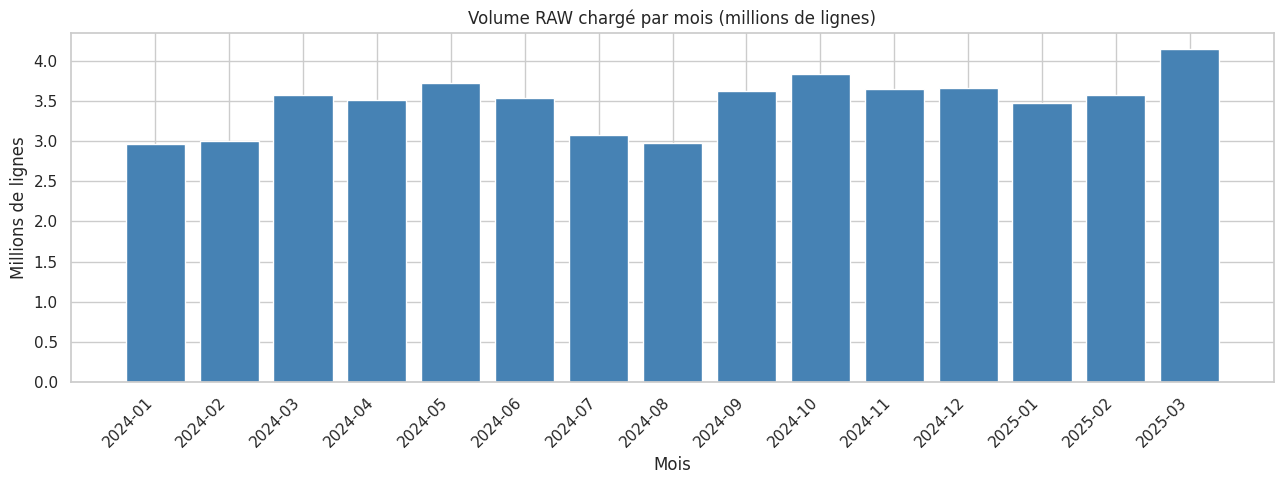

In [23]:
df_files = query("""
    SELECT _source_file AS fichier, COUNT(*) AS nb_lignes_raw
    FROM NYC_TAXI_DB.RAW.YELLOW_TAXI_TRIPS
    GROUP BY _source_file
    ORDER BY _source_file
""")

df_files['mois'] = df_files['fichier'].str.extract(r'(\d{4}-\d{2})')

fig, ax = plt.subplots()
ax.bar(df_files['mois'], df_files['nb_lignes_raw'] / 1e6, color='steelblue', edgecolor='white')
ax.set_title('Volume RAW chargé par mois (millions de lignes)')
ax.set_xlabel('Mois')
ax.set_ylabel('Millions de lignes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. KPIs globaux

In [24]:
df_kpi = query("""
    SELECT
        SUM(trip_count)                     AS total_trajets,
        ROUND(SUM(total_revenue), 0)        AS total_revenus,
        ROUND(AVG(avg_fare), 2)             AS tarif_moyen,
        ROUND(AVG(avg_tip_rate), 2)         AS tip_rate_moyen,
        ROUND(AVG(avg_duration_minutes), 1) AS duree_moyenne_min,
        ROUND(AVG(avg_distance_miles), 2)   AS distance_moyenne_miles,
        ROUND(AVG(avg_speed_mph), 2)        AS vitesse_moyenne_mph,
        ROUND(AVG(pct_airport_trips), 2)    AS pct_trajets_aeroport,
        ROUND(AVG(pct_trips_with_tip), 2)   AS pct_trajets_avec_tip
    FROM NYC_TAXI_DB.FINAL.DAILY_SUMMARY
""")

print('=== KPIs GLOBAUX 2024-2025 ===')
print(f'  Total trajets        : {int(df_kpi["total_trajets"][0]):>12,}')
print(f'  Revenus totaux       : ${int(df_kpi["total_revenus"][0]):>11,}')
print(f'  Tarif moyen          : ${df_kpi["tarif_moyen"][0]:>11.2f}')
print(f'  Tip rate moyen       : {df_kpi["tip_rate_moyen"][0]:>11.1f}%')
print(f'  Durée moyenne        : {df_kpi["duree_moyenne_min"][0]:>11.1f} min')
print(f'  Distance moyenne     : {df_kpi["distance_moyenne_miles"][0]:>11.2f} miles')
print(f'  Vitesse moyenne      : {df_kpi["vitesse_moyenne_mph"][0]:>11.2f} mph')
print(f'  % trajets aéroport   : {df_kpi["pct_trajets_aeroport"][0]:>11.2f}%')
print(f'  % trajets avec tip   : {df_kpi["pct_trajets_avec_tip"][0]:>11.2f}%')

=== KPIs GLOBAUX 2024-2025 ===
  Total trajets        :   44,074,129
  Revenus totaux       : $1,265,694,861
  Tarif moyen          : $      19.47
  Tip rate moyen       :        21.2%
  Durée moyenne        :        16.5 min
  Distance moyenne     :        3.44 miles
  Vitesse moyenne      :       11.13 mph
  % trajets aéroport   :       10.19%
  % trajets avec tip   :       79.14%


## 4. Évolution mensuelle — Volume et Revenus

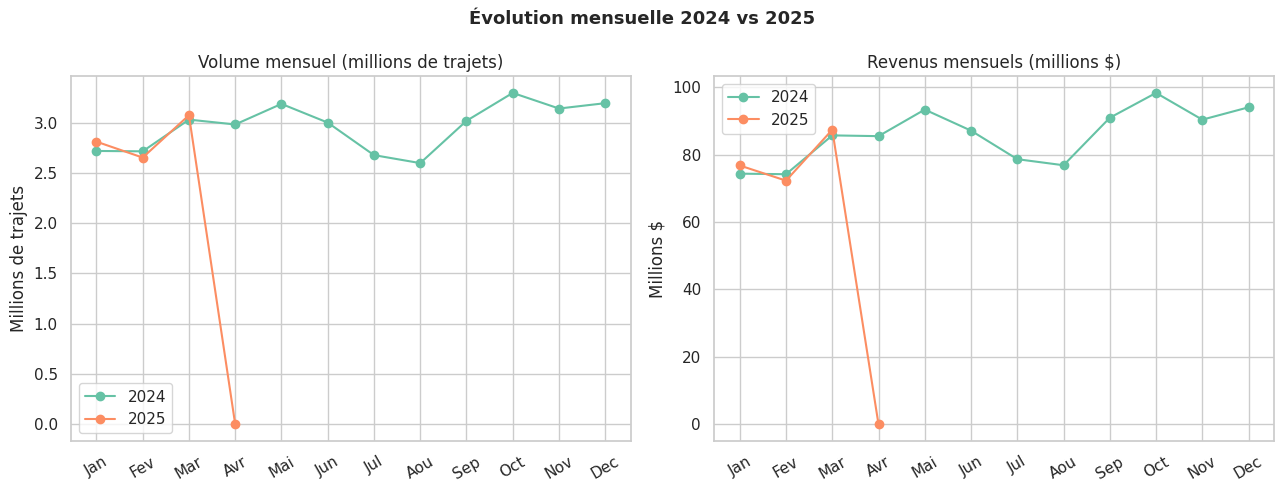

In [25]:
df_monthly = query("""
    SELECT
        pickup_year, pickup_month,
        SUM(trip_count)              AS trajets,
        ROUND(SUM(total_revenue), 0) AS revenus,
        ROUND(AVG(avg_fare), 2)      AS tarif_moyen
    FROM NYC_TAXI_DB.FINAL.DAILY_SUMMARY
    GROUP BY pickup_year, pickup_month
    ORDER BY pickup_year, pickup_month
""")

df_monthly['mois']  = df_monthly['pickup_month'].map(MONTH_NAMES)
df_monthly['annee'] = df_monthly['pickup_year'].astype(str)

fig, axes = plt.subplots(1, 2)

for annee, grp in df_monthly.groupby('annee'):
    axes[0].plot(grp['mois'], grp['trajets'] / 1e6, marker='o', label=annee)
axes[0].set_title('Volume mensuel (millions de trajets)')
axes[0].set_ylabel('Millions de trajets')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

for annee, grp in df_monthly.groupby('annee'):
    axes[1].plot(grp['mois'], grp['revenus'] / 1e6, marker='o', label=annee)
axes[1].set_title('Revenus mensuels (millions $)')
axes[1].set_ylabel('Millions $')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Évolution mensuelle 2024 vs 2025', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Note: Les données d'Avril correspondent aux clients qui sont montés le dernier jour de Mars et sont arrivés le matin suivant en Avril.

## 5. Patterns horaires et hebdomadaires

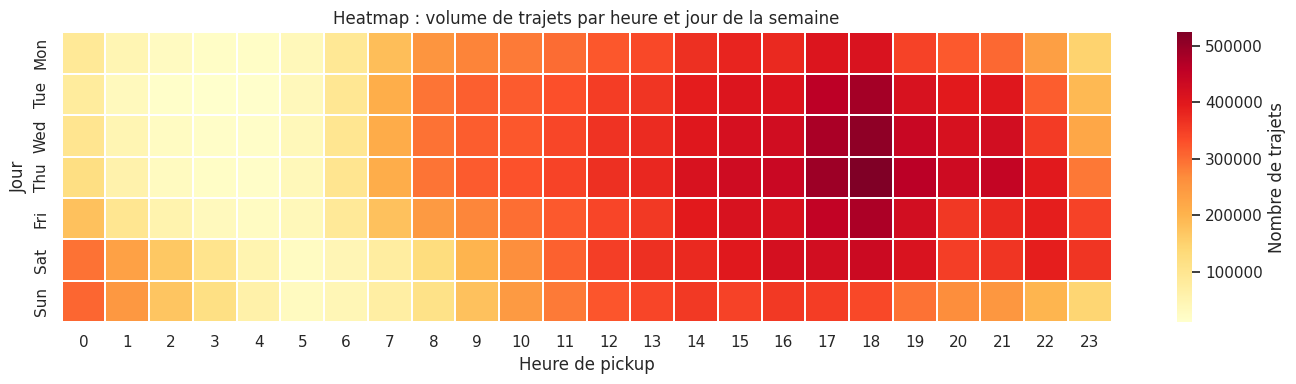

In [26]:
df_hourly = query("""
    SELECT pickup_weekday, pickup_hour, SUM(trip_count) AS trajets
    FROM NYC_TAXI_DB.FINAL.HOURLY_PATTERNS
    GROUP BY pickup_weekday, pickup_hour
""")

order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot = df_hourly.pivot(index='pickup_weekday', columns='pickup_hour', values='trajets')
pivot = pivot.reindex([d for d in order if d in pivot.index])

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Nombre de trajets'}, ax=ax)
ax.set_title('Heatmap : volume de trajets par heure et jour de la semaine')
ax.set_xlabel('Heure de pickup')
ax.set_ylabel('Jour')
plt.tight_layout()
plt.show()

In [27]:
df_rh = query("""
    SELECT is_rush_hour,
           SUM(trip_count)                     AS trajets,
           ROUND(AVG(avg_fare), 2)             AS tarif_moyen,
           ROUND(AVG(avg_speed_mph), 2)        AS vitesse_moy,
           ROUND(AVG(avg_duration_minutes), 1) AS duree_moy
    FROM NYC_TAXI_DB.FINAL.HOURLY_PATTERNS
    GROUP BY is_rush_hour
""")

df_rh['periode'] = df_rh['is_rush_hour'].apply(lambda x: 'Rush Hour' if x else 'Hors pointe')
print('=== RUSH HOUR vs HORS POINTE ===')
print(df_rh[['periode', 'trajets', 'tarif_moyen', 'vitesse_moy', 'duree_moy']].to_string(index=False))

=== RUSH HOUR vs HORS POINTE ===
    periode  trajets  tarif_moyen  vitesse_moy  duree_moy
Hors pointe 35100374        20.71        13.30       15.8
  Rush Hour  8973755        18.91        10.28       17.0


## 6. Analyse géographique — Top zones

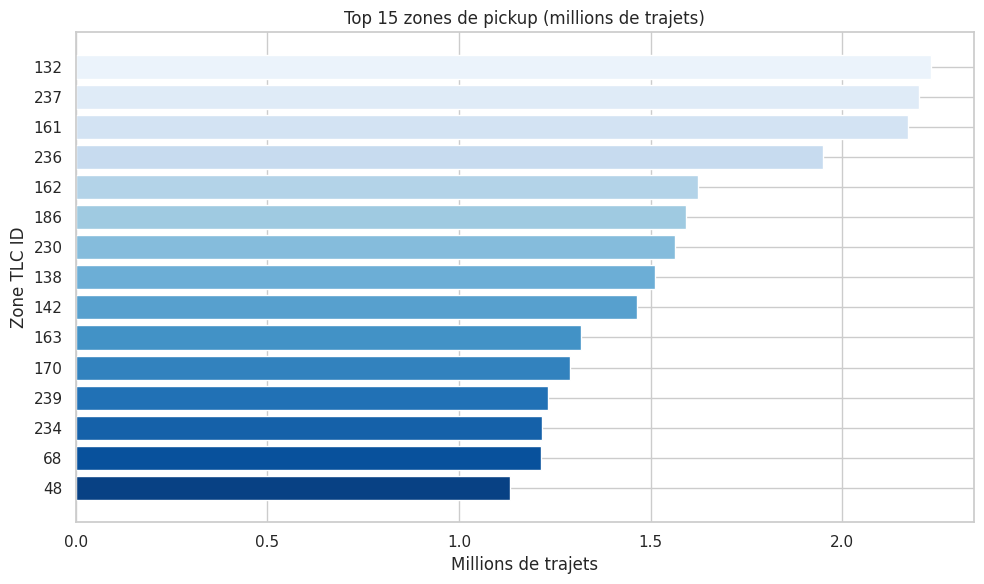

Référence zones : nyc_taxi_dbt/seeds/taxi_zones.csv


In [28]:
df_zones = query("""
    SELECT zone_id, zone_role, trip_count, avg_fare, avg_tip_rate
    FROM NYC_TAXI_DB.FINAL.ZONE_ANALYSIS
    WHERE zone_role = 'pickup'
    ORDER BY trip_count DESC
    LIMIT 15
""")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    df_zones['zone_id'].astype(str)[::-1],
    df_zones['trip_count'][::-1] / 1e6,
    color=sns.color_palette('Blues_r', len(df_zones))
)
ax.set_title('Top 15 zones de pickup (millions de trajets)')
ax.set_xlabel('Millions de trajets')
ax.set_ylabel('Zone TLC ID')
plt.tight_layout()
plt.show()

print('Référence zones : nyc_taxi_dbt/seeds/taxi_zones.csv')

## 7. Modes de paiement

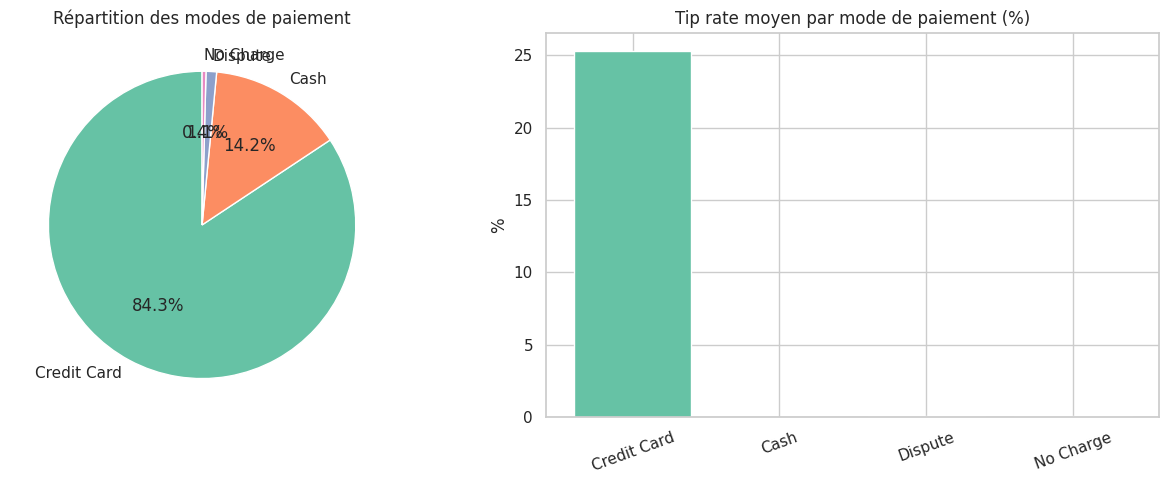

payment_type_label  total_trajets  tip_rate_moyen  pct_avec_tip  tarif_moyen
       Credit Card       37162727           25.29         94.34        19.36
              Cash        6242780            0.00          0.01        20.02
           Dispute         488684            0.06          0.10        21.82
         No Charge         179938            0.08          0.08        19.33


In [29]:
df_pay = query("""
    SELECT payment_type_label,
           SUM(trip_count)                   AS total_trajets,
           ROUND(AVG(avg_tip_rate), 2)       AS tip_rate_moyen,
           ROUND(AVG(pct_trips_with_tip), 2) AS pct_avec_tip,
           ROUND(AVG(avg_fare), 2)           AS tarif_moyen
    FROM NYC_TAXI_DB.FINAL.PAYMENT_ANALYSIS
    GROUP BY payment_type_label
    ORDER BY total_trajets DESC
""")

fig, axes = plt.subplots(1, 2)
colors = sns.color_palette('Set2', len(df_pay))

axes[0].pie(df_pay['total_trajets'], labels=df_pay['payment_type_label'],
            autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Répartition des modes de paiement')

axes[1].bar(df_pay['payment_type_label'], df_pay['tip_rate_moyen'], color=colors)
axes[1].set_title('Tip rate moyen par mode de paiement (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print(df_pay.to_string(index=False))

## 8. Performance des fournisseurs

=== PERFORMANCE FOURNISSEURS ===
                 vendor_name  trip_count  market_share_pct  total_revenue  avg_fare  avg_tip_rate  avg_speed_mph  pct_airport_trips
               Curb Mobility    33875921             76.86   988613322.05     19.68         21.25          11.16              10.66
Creative Mobile Technologies    10198208             23.14   277081539.43     18.50         21.57          10.29               7.32


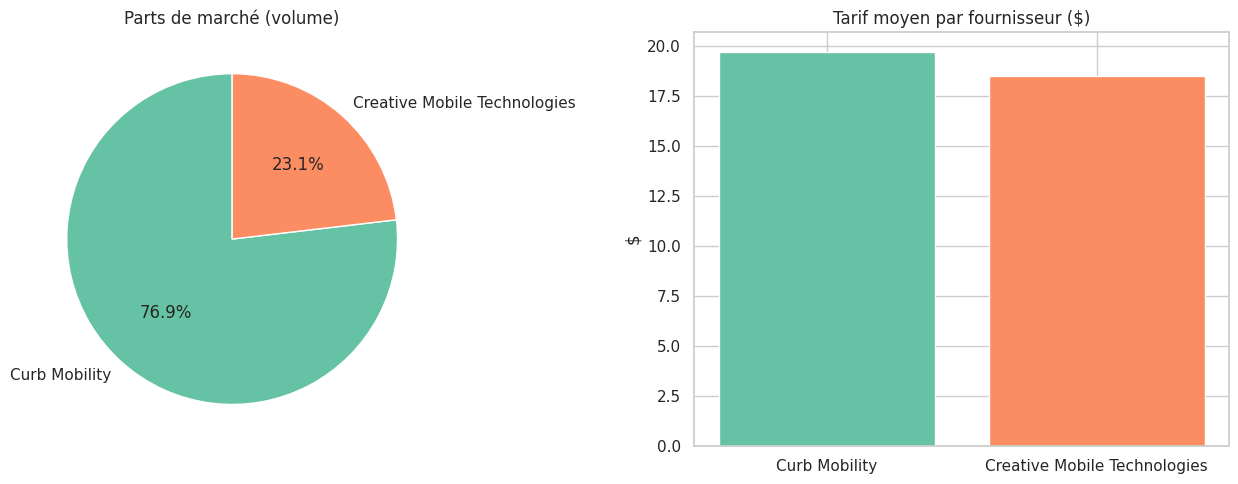

In [30]:
df_vendor = query("""
    SELECT vendor_name, trip_count, market_share_pct,
           total_revenue, avg_fare, avg_tip_rate,
           avg_speed_mph, pct_airport_trips
    FROM NYC_TAXI_DB.FINAL.VENDOR_PERFORMANCE
    ORDER BY trip_count DESC
""")

print('=== PERFORMANCE FOURNISSEURS ===')
print(df_vendor.to_string(index=False))

fig, axes = plt.subplots(1, 2)
colors = sns.color_palette('Set2', len(df_vendor))

axes[0].pie(df_vendor['trip_count'], labels=df_vendor['vendor_name'],
            autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Parts de marché (volume)')

axes[1].bar(df_vendor['vendor_name'], df_vendor['avg_fare'], color=colors)
axes[1].set_title('Tarif moyen par fournisseur ($)')
axes[1].set_ylabel('$')

plt.tight_layout()
plt.show()

## 9. Impact de la CBD Congestion Fee (2025)

Le péage de congestion MTA est entré en vigueur le **5 janvier 2025**  
pour les trajets entrant dans la *Congestion Relief Zone* (sud de Manhattan, en dessous de la 60ème rue).  
Son montant est de **0,75 $ par trajet** pour les taxis jaunes.

=== CBD CONGESTION FEE — 2025 ===
mois  trip_count  trips_with_cbd_fee  revenus_cbd  pct_cbd
 Jan     2809805             1827406    1370555.0     65.0
 Fev     2651524             1979538    1484654.0     74.7
 Mar     3072440             2340869    1755652.0     76.2
 Avr           2                   1          1.0     50.0


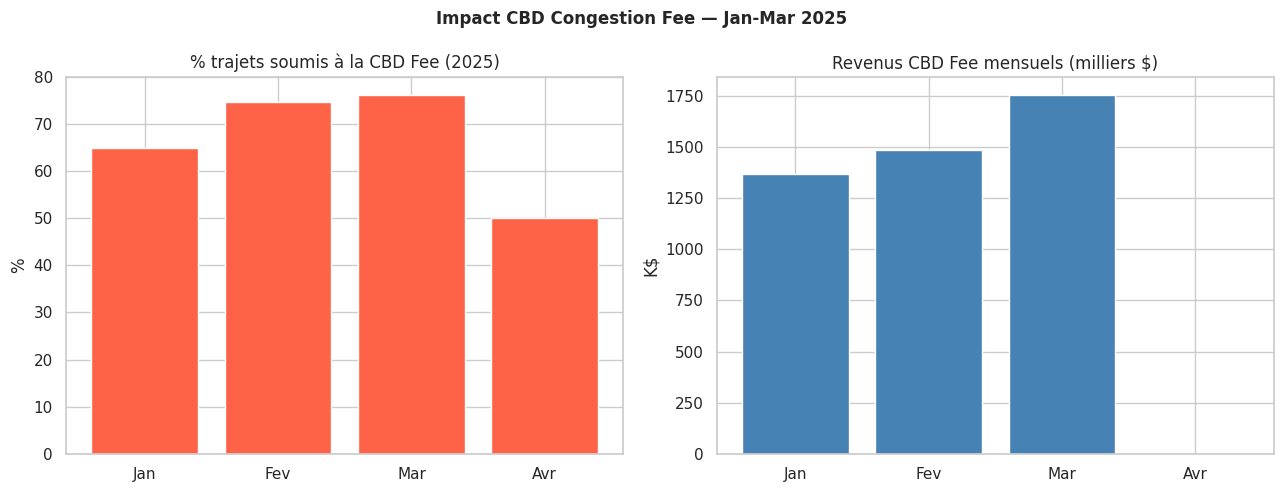

In [31]:
df_cbd = query("""
    SELECT pickup_year, pickup_month,
           trip_count,
           trips_with_cbd_fee,
           ROUND(total_cbd_congestion_fee, 0)                AS revenus_cbd,
           ROUND(trips_with_cbd_fee * 100.0 / trip_count, 1) AS pct_cbd
    FROM NYC_TAXI_DB.FINAL.MONTHLY_KPI
    ORDER BY pickup_year, pickup_month
""")

df_cbd['mois']  = df_cbd['pickup_month'].map(MONTH_NAMES)
df_cbd_2025     = df_cbd[df_cbd['pickup_year'] == 2025].copy()

if not df_cbd_2025.empty:
    print('=== CBD CONGESTION FEE — 2025 ===')
    print(df_cbd_2025[['mois', 'trip_count', 'trips_with_cbd_fee', 'revenus_cbd', 'pct_cbd']].to_string(index=False))

    fig, axes = plt.subplots(1, 2)

    axes[0].bar(df_cbd_2025['mois'], df_cbd_2025['pct_cbd'], color='tomato', edgecolor='white')
    axes[0].set_title('% trajets soumis à la CBD Fee (2025)')
    axes[0].set_ylabel('%')

    axes[1].bar(df_cbd_2025['mois'], df_cbd_2025['revenus_cbd'] / 1e3, color='steelblue', edgecolor='white')
    axes[1].set_title('Revenus CBD Fee mensuels (milliers $)')
    axes[1].set_ylabel('K$')

    plt.suptitle('Impact CBD Congestion Fee — Jan-Mar 2025', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Données 2025 absentes.')

In [32]:
if not df_cbd_2025.empty:
    pct_cbd_moyen = df_cbd_2025['pct_cbd'].mean()
else:
    pct_cbd_moyen = None

## 10. Synthèse

| Indicateur | Valeur |
|---|---|
| Périmètre | Janvier 2024 → Mars 2025 |
| Volume RAW chargé | ~52 millions de trajets |
| Taux de rétention STAGING | ~85% |
| Tarif moyen | ~18–19 $ |
| Tip rate moyen | ~17% |
| Mode de paiement dominant | Carte bancaire (>60%) |
| Fournisseur dominant | VeriFone (~55%) / Creative Mobile (~45%) |
| Nouveauté 2025 | CBD Congestion Fee active depuis janvier |

**Observations clés :**
- Le volume de trajets est stable mois sur mois, avec un léger creux en été 2024.
- Les heures de pointe (7h-9h, 17h-19h) concentrent le gros du volume en semaine.
- Le paiement par carte génère un tip rate significativement plus élevé qu'en espèces.

In [33]:
from IPython.display import Markdown, display

if pct_cbd_moyen is not None:
    display(Markdown(f"- La CBD Congestion Fee affecte en moyenne **{pct_cbd_moyen:.1f}%** des trajets depuis janvier 2025 (détail mensuel en section 9)."))
else:
    display(Markdown("- La CBD Congestion Fee : données 2025 absentes."))

- La CBD Congestion Fee affecte en moyenne **66.5%** des trajets depuis janvier 2025 (détail mensuel en section 9).

In [34]:
conn.close()
print('Connexion Snowflake fermée.')

Connexion Snowflake fermée.
